# Load and Analyze Ohmic Results

This is to generate the plot in Figure 1 in arXiv:2603.25708 by loading stored poles and weights for approximating bath correlation functions of Ohmic density on $[0,T]$ for various values of $T$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.serif'] = ['Times New Roman']


## Extract and Display Poles and Weights

In [2]:
# Load the ohmic.npz file
data = np.load("ohmic.npz", allow_pickle=True)
# Extract poles and weights for each T value
print("Extracted Poles and Weights:")
print("=" * 60)

poles_dict = {}
weights_dict = {}

for key in data.files:
    if key.startswith('poles_T='):
        T_val = float(key.replace('poles_T=', ''))
        poles_dict[T_val] = data[key]
        print(f"\nT = {T_val}:")
        print(f"  Poles: {data[key]}")
    elif key.startswith('weights_T='):
        T_val = float(key.replace('weights_T=', ''))
        weights_dict[T_val] = data[key]
        print(f"  Weights: {data[key]}")

Extracted Poles and Weights:

T = 4.0:
  Poles: [0.31168797-0.44163121j 1.32247008-1.41265568j 3.69062028-2.72569655j]
  Weights: [ 0.05969169-0.36658243j  0.99458265-0.05965502j -0.0574787 +0.42854204j]

T = 5.6:
  Poles: [0.16012535-0.30860913j 0.69346009-1.04535731j 1.9569768 -2.15435257j
 4.61357705-3.5249231j ]
  Weights: [-0.04625705-0.17330042j  0.55141885-0.55690099j  0.68383127+0.58890485j
 -0.18956676+0.14065041j]

T = 8.0:
  Poles: [0.10698864-0.26269488j 0.5281126 -0.92347643j 1.65932249-1.96411527j
 4.1884882 -3.27850953j]
  Weights: [-0.05937172-0.11371693j  0.36344057-0.5932195j   0.8942138 +0.457217j
 -0.19987612+0.24923698j]

T = 11.2:
  Poles: [0.07376884-0.22225672j 0.41939082-0.81713873j 1.45565876-1.80380079j
 3.88850653-3.07863767j]
  Weights: [-0.05565225-0.07373581j  0.21771064-0.56544505j  1.01288831+0.29086682j
 -0.17759631+0.34863514j]

T = 16.0:
  Poles: [0.05094582-0.18543187j 0.33884572-0.72021567j 1.29583147-1.65984903j
 3.64457073-2.90209952j]
  Weights:

## Verify fitting Error is smaller than threshold

In [3]:
fit_tol = 1e-2
# Define correlation function
def Corr(t, wc=1.0):
    return (wc / (1 + 1j*wc*t))**2


# Verify reconstruction for each T
dt = 0.01
tlist_all = np.arange(102401) * dt
Ct_all = Corr(tlist_all)

print("Reconstruction Errors:")
print("=" * 60)
N_pol = []
for T_val in sorted(poles_dict.keys()):
    poles = poles_dict[T_val]
    weights = weights_dict[T_val]
    
    tlist_here = tlist_all[tlist_all <= T_val]
    Clist_here = Ct_all[tlist_all <= T_val]
    
    # Reconstruct using Vandermonde matrix
    Van_here = np.exp(-1j * tlist_here[:, None] * poles)
    Clist_recon = Van_here @ weights
    
    error = np.sum(np.abs(Clist_here - Clist_recon)) * dt
    if error < fit_tol:
        print(f"T = {T_val}: error = {error:.4e} (PASS)")
    else:
        print(f"T = {T_val}: error = {error:.4e} (FAIL)")
    N_pol.append(len(poles))

Reconstruction Errors:
T = 4.0: error = 5.0447e-03 (PASS)
T = 5.6: error = 1.2751e-03 (PASS)
T = 8.0: error = 2.8355e-03 (PASS)
T = 11.2: error = 5.1835e-03 (PASS)
T = 16.0: error = 8.7359e-03 (PASS)
T = 22.4: error = 2.7933e-03 (PASS)
T = 32.0: error = 4.3957e-03 (PASS)
T = 45.0: error = 6.2949e-03 (PASS)
T = 64.0: error = 8.5492e-03 (PASS)
T = 90.0: error = 3.2731e-03 (PASS)
T = 128.0: error = 4.3263e-03 (PASS)
T = 180.0: error = 5.4353e-03 (PASS)
T = 256.0: error = 6.5268e-03 (PASS)
T = 360.0: error = 7.4536e-03 (PASS)
T = 512.0: error = 8.1852e-03 (PASS)
T = 724.0: error = 8.6477e-03 (PASS)
T = 1024.0: error = 8.8395e-03 (PASS)


## Plot Reconstructed vs Original Correlation

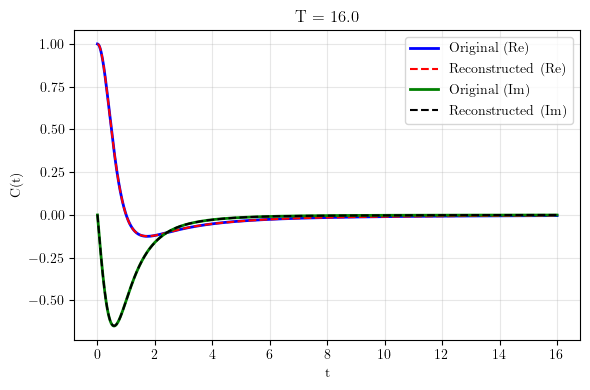

In [4]:
# Plot reconstructed correlation for a few T values
fig, ax = plt.subplots(figsize=(6, 4))

for T_val in [16.0]:
    poles = poles_dict[T_val]
    weights = weights_dict[T_val]
    
    tlist_here = tlist_all[tlist_all <= T_val]
    Clist_here = Ct_all[tlist_all <= T_val]
    
    # Reconstruct
    Van_here = np.exp(-1j * tlist_here[:, None] * poles)
    Clist_recon = Van_here @ weights
    
    # Plot
    ax.plot(tlist_here, np.real(Clist_here), 'b-', label='Original (Re)', linewidth=2)
    ax.plot(tlist_here, np.real(Clist_recon), 'r--', label='Reconstructed (Re)', linewidth=1.5)
    ax.plot(tlist_here, np.imag(Clist_here), 'g-', label='Original (Im)', linewidth=2)
    ax.plot(tlist_here, np.imag(Clist_recon), 'k--', label='Reconstructed (Im)', linewidth=1.5)
    
    ax.set_title(f'T = {T_val}')
    ax.set_xlabel('t')
    ax.set_ylabel('C(t)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Plot figure 1

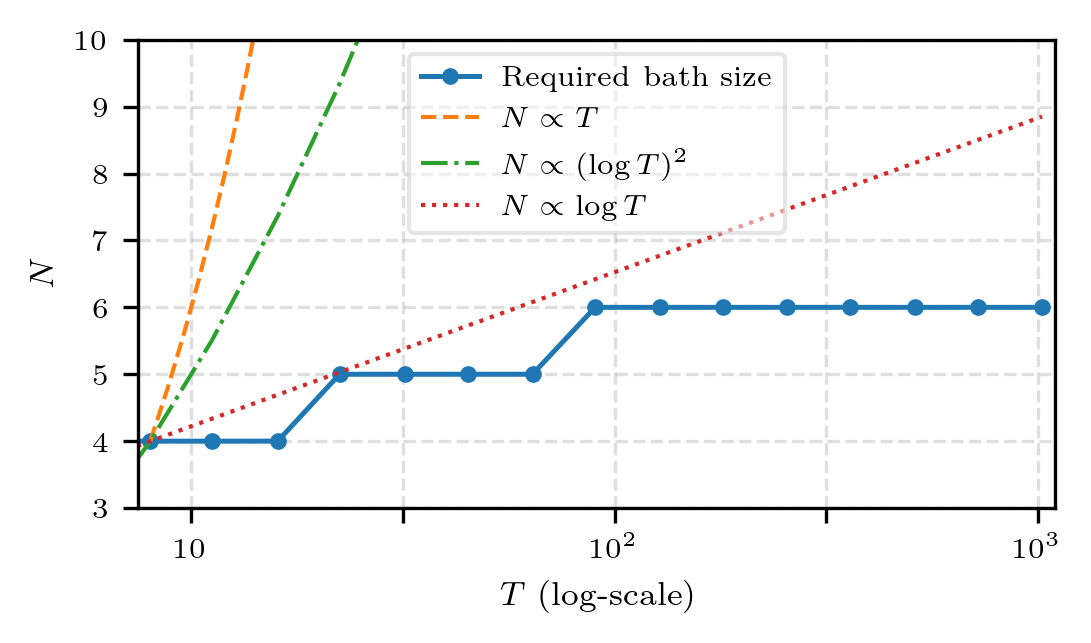

In [5]:
T = list(poles_dict.keys())

fig, ax = plt.subplots(figsize=(3.5, 2.0), dpi=300, facecolor='w')
# plot N_pol vs T on a log-log scale
ax.plot(T, N_pol, marker='o', linestyle='-', color='C0', linewidth=1.2, markersize=3, label='Required bath size')

# Reference scalings anchored at the first point (T[2], N[2])
k_lin = 1
k_log = N_pol[2] / np.log(T[2])
k_log2 = N_pol[2] / (np.log(T[2]) ** 2)
# Plot reference lines for N ~ T
ax.plot(8*np.arange(1,  10,0.1), N_pol[2] + k_lin * (8*np.arange(1, 10, 0.1) - T[2]), linestyle='--', color='C1', linewidth=1.0, label=r'$N\propto T$')
# Plot reference lines for N ~ log^2(T) 
ax.plot(T,   (np.log(T) ** 2) +N_pol[2] - (np.log(T[2]) ** 2), linestyle='-.', color='C2', linewidth=1.0, label=r'$N\propto (\log T)^2$')
# Plot reference lines for N ~ log(T)
ax.plot(T,   np.log(T)  + N_pol[2] - np.log(T[2]), linestyle=':', color='C3', linewidth=1.0, label=r'$N\propto \log T$')

ax.set_xscale('log', base=2)
ax.set_xticks([10, pow(10,1.5), pow(10,2), pow(10,2.5), pow(10,3)])
ax.set_xticklabels([r'$10$',"", r'$10^{2}$', "",r'$10^{3}$'])
ax.set_xlabel(r'$T$ ($\log$-scale)', fontsize=8)
ax.set_ylabel(r'$N$', fontsize=8)
ax.set_ylim([3, 10])

ax.set_xlim([7.5, 1100])
ax.tick_params(labelsize=7)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(fontsize=7, loc='upper center', framealpha = 0.5)

plt.tight_layout(pad=0.2)
plt.savefig('n_vs_t.pdf', dpi=300, bbox_inches='tight')
plt.show()
